# Two Ways to Color a Map

In this notebook I aim to design two different colormaps, sequential and diverging, to answer two different questions using the same dataset. This is a study about the choices involved in designing colormaps. Choosing between sequential or diverging color scales can mean choosing between two completely different stories told to the viewer.

**Data.** UNEP-WCMC and IUCN (2026), *Protected Planet: WDPA and WD-OECM*, March 2026,
Cambridge, UK. [protectedplanet.net](https://www.protectedplanet.net). Country land areas come
from the `countryinfo` package, since the WDPA export does not carry them.

For this notebook, I reused the dataset from [notebook 2](02-protected-area-distributions.ipynb), containing information about all protected areas in the world. I only included terrestrial areas for this task as the dataset does not contain enough location information to map marine areas onto the map. The dataset is not primarily made for this kind of data and therefore has a few errors (e.g., Denmark) and does not include information about all countries. I fixed this for the [next notebook](07-protection-heatmap-clustermap.ipynb) by using a dataset more suitable for this job.


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from style import use_report_style

use_report_style()

import plotly.graph_objects as go
import plotly.io as pio
from countryinfo import CountryInfo

In [2]:
areas = pd.read_csv(
    "../data/protected_areas.csv",
    usecols=["PRNT_ISO3", "GIS_AREA", "REALM", "DESIG_TYPE"],
    low_memory=False,
)

areas = areas[(areas["REALM"] == "Terrestrial") & (areas["DESIG_TYPE"] == "National")]

by_country = areas.groupby("PRNT_ISO3")["GIS_AREA"].sum().reset_index()

# remove multi-country designations ("FRA;ESP") and areas beyond national jurisdiction
by_country = by_country[~by_country["PRNT_ISO3"].str.contains(";|ABNJ", na=False)]
by_country = by_country.rename(columns={"GIS_AREA": "Protected_Area"})

print(f"{len(by_country)} countries")
by_country.head()

187 countries


,PRNT_ISO3,Protected_Area
0,AFG,55288.922809
1,AGO,147534.861025
2,ALB,4702.662475
3,AND,95.707382
4,ARE,13080.584998


In [3]:
def land_area(iso3):
    """Total land area for an ISO3 code, or None when the package has no entry."""
    try:
        return CountryInfo(iso3).area()
    except Exception:
        return None


by_country["Country_Area"] = by_country["PRNT_ISO3"].apply(land_area)
by_country["Area_Percent"] = (
    by_country["Protected_Area"].astype(float) / by_country["Country_Area"].astype(float) * 100
)

missing = by_country["Area_Percent"].isna().sum()
print(f"{missing} countries with missing area. Rendered grey")

by_country.sort_values("Area_Percent", ascending=False).head(10)

2 countries with missing area. Rendered grey


,PRNT_ISO3,Protected_Area,Country_Area,Area_Percent
49,DNK,9.771951e+05,43094.0,2267.589615
159,SVN,1.468404e+04,20273.0,72.431499
180,VEN,6.637231e+05,916445.0,72.423667
104,LUX,1.654955e+03,2586.0,63.996718
113,MLT,1.967444e+02,316.0,62.260887
44,CYP,5.251957e+03,9251.0,56.771780
28,BTN,2.027120e+04,38394.0,52.797825
51,DZA,1.231445e+06,2381741.0,51.703583
100,LIE,8.248986e+01,160.0,51.556161
156,STP,4.673804e+02,964.0,48.483446


## Sequential: how much does each country protect?

For this visualization, I used a sequential colormap where mostly luminance is used to convey information. This is the best choice since luminance shows the highest level of detail and it is intuitive to understand that lower luminance levels (i.e., darker shades) correspond to higher data values.


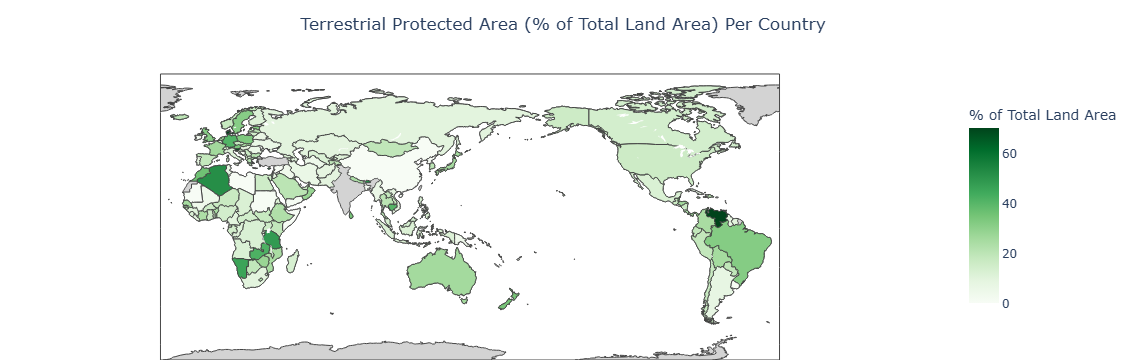

In [4]:
sequential = go.Figure(go.Choropleth(
    locations=by_country["PRNT_ISO3"],
    locationmode="ISO-3",
    z=by_country["Area_Percent"].astype(float),
    colorscale="Greens",
    zmin=0,
    zmax=70,
    colorbar_title="% of Total Land Area",
))

sequential.update_geos(landcolor="lightgray")
sequential.update_layout(
    geo_scope="world",
    margin=dict(l=0, r=0, t=50, b=0),
    title=dict(
        text="Terrestrial Protected Area (% of Total Land Area) Per Country",
        y=0.95, x=0.5, xanchor="center",
    ),
)
sequential.data[0].update(colorbar=dict(len=0.7, y=0.5, x=1.02, title_side="top"))

# GitHub does not render plotly output -> a static copy for the README
pio.write_image(sequential, "../figures/06-choropleth-sequential.png",
                width=1200, height=600, scale=2)
sequential.show()

![Sequential choropleth of terrestrial protected area by country](../figures/06-choropleth-sequential.png)

*A static copy of the interactive plotly map above that doesn't render on GitHub*


This colormap shows the percentage of national protected terrestrial area for each country. It shows which countries protect their nature the most, which is useful information when considering possible actions toward SDG 15. Countries such as Brazil, Tanzania, Venezuela, Cambodia and Algeria have most protected area relative to the size of the country, which is especially surprising considering their large size. China stands out as a large country with little land protected.

An important design choice is that countries with no data have a default color of gray, making them distinguishable from countries with close to zero protected area.


## Diverging: how does each country compare to Finland?

In the second colormap, I use a diverging colormap where, in addition to luminance showing the distance from zero value, hue is used to separate positive values from the negative. For the human eye, blue and red are easily distinguishable, even with the most common form of dichromacy.


Finland protects 11.0% of its land area


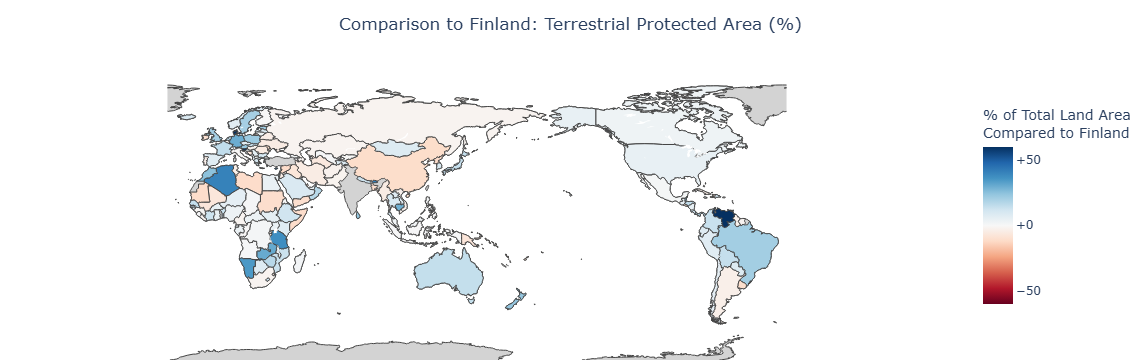

In [5]:
finland = by_country.loc[by_country["PRNT_ISO3"] == "FIN", "Area_Percent"].item()
by_country["Compared_To_Finland"] = by_country["Area_Percent"] - finland

print(f"Finland protects {finland:.1f}% of its land area")

diverging = go.Figure(go.Choropleth(
    locations=by_country["PRNT_ISO3"],
    locationmode="ISO-3",
    z=by_country["Compared_To_Finland"].astype(float),
    colorscale="RdBu",
    zmin=-60,
    zmax=60,
    colorbar=dict(title="% of Total Land Area<br>Compared to Finland", tickformat="+"),
))

diverging.update_geos(landcolor="lightgray")
diverging.update_layout(
    geo_scope="world",
    margin=dict(l=0, r=0, t=50, b=0),
    geo=dict(showframe=False, showcoastlines=True),
    title=dict(
        text="Comparison to Finland: Terrestrial Protected Area (%)",
        y=0.95, x=0.5, xanchor="center",
    ),
)
diverging.data[0].update(colorbar=dict(len=0.7, y=0.5, x=1.02, title_side="top"))

pio.write_image(diverging, "../figures/06-choropleth-diverging.png",
                width=1200, height=600, scale=2)
diverging.show()

![Diverging choropleth comparing each country to Finland](../figures/06-choropleth-diverging.png)

*Static copy of the interactive map above.*

In the diverging colormap, the data has been transformed to have Finland’s percentage of protected land area as the point of comparison. Now, in addition to the same countries standing out, countries that have protected their nature less than Finland stand out as well, revealing differences to Finland. Interpreting this map by itself would be difficult as one would need to know about nature protection in Finland. That is why the visualization should probably show the absolute value for Finland. 

**Design notes:** I used plotly rather than matplotlib for the hover interactivity. As the dataset did not include information about the total area of the countries, I used a library called countryinfo that fetches data from Wikipedia. Plotting the protected areas onto a map was exhaustive as there are different types of protected areas – some of which belonging to multiple countries and some not belonging to any country.
